### Its a good idea to write and test your functions (without LLM) before creating the agent


In [ ]:
### molnum tool: Determine number of solvent molecules for box 

def molnum(dens:float, mm:float, lx:float) -> int:
    """Function to determine number of molecules required for a given cubic box size and density"""

    # Determine volume of the simulation box and change to m 
    vol_a = lx*ly*lz ##A^3

    ## 1 A = 10^-7 m
    arm = 10**(-10) #m 
    vol_m = vol_a* arm**3 ##m^3

    # Use inputs to determine molarity (mol/cm3) 
    molarity_cm = dens/mm # mol/cm3
    molarity_m = molarity_cm*(100**3)  #mol/m3

    # Define avogadro's number
    Na = 6.022*(10**23) ## particle/mol

    # Determine the number of molecules and print results
    num = molarity_m*vol_m*Na

    ## Print results 
    print('Box size: ', vol_a,'Armstrong^3')
    print('Density of :', dens, 'g/cm3')
    print('The required number of molecules is: ',round(num))

    return 

## Test the function
molnum(0.789, 46.07, 25.0)



Box size:  15625.0 Armstrong^3
Density of : 0.789 g/cm3
The required number of molecules is:  161


In [18]:
def create_lammps_data_file(name:str, smiles:str, box_size:float, n_molecs:int):
   #### SMILES to Lammps Data file
    import mbuild
    import foyer 
    import warnings
    warnings.filterwarnings("ignore")

    """Function to create a data file for LAMMPS simulations using only 1 input. The input is a smiles string of a molecule."""
    #Define inputs 
    system_smiles = smiles     ##'CCO'  # Ethanol for example
    box_size = box_size # nano meter = 
    n_molecules = n_molecs # Number of molecules
    #density = 789 ## kg/m^3
    forcefield_name = 'oplsaa' # OPLS-AA forcefield. Can be changed by available forcefileds in mbuild
    system_name = name # Name of the system


    # Load system using its SMILES strings
    system_unparad = mbuild.load(system_smiles, smiles=True)

    # assign name 
    system_unparad.name = system_name

    # build box
    box = mbuild.Box(3*[box_size])

    # Fill the box with the molecule of interest
    # filled_box = mbuild.fill_box(compound=system_unparad, density=density, box=box, overlap=0.2)
    filled_box = mbuild.fill_box(compound=system_unparad, n_compounds=n_molecules, box=box, overlap=0.2)

    ## apply the forcefield to the system
    ff = foyer.Forcefield(name=forcefield_name)
    filled_box_param = filled_box.to_parmed(infer_residues=True) # Parmed structure
    filled_box_parametrized = ff.apply(filled_box_param) # ff applied

    ## Pass the parametrized system to a Lammps data file 
    mbuild.formats.lammpsdata.write_lammpsdata(
    filled_box_parametrized, 
    str(system_name)+".data",
    atom_style="full",
    unit_style="real",
    use_rb_torsions=True,)

    return

## test the function
create_lammps_data_file('ethanol','CCO', 3.0, 150)

No urey bradley terms detected, will use angle_style harmonic
RB Torsions detected, will use dihedral_style opls


In [ ]:
def create_lammps_input_file(input_file,data_file,Temp=298.0,Pres=1.0):

    with open(f'{input_file}', 'w') as file:
        print(f'''
atom_style full
units real
boundary p p p
pair_style lj/cut/coul/long 12.0
kspace_style pppm 1.0e-4
bond_style harmonic
angle_style harmonic
dihedral_style opls

# ----------------- Atom Definition Section -----------------
read_data "{data_file}"

thermo 100

#  -- minimize -- (Minimization without fix shake)
minimize 1.0e-5 1.0e-7 1000 10000
reset_timestep 0
write_data system_minimized.data

# ----------------- Run Section -----------------              
# Setup timestep
timestep        1 #fs

# Define thermo output
thermo          1000
thermo_style    custom step time temp pe ke etotal enthalpy press lx vol density

#Create initial velocity distribution
velocity   all create {Temp} 097865 dist gaussian

## Fix commands
fix 1 all npt temp {Temp} {Temp} 100 iso {Pres} {Pres} 1000.0

# Define Dumping
#dump 1 all xyz 1000 test.xyz
dump 3 all dcd 1000 npt_trajectory.dcd

run 1000000 # 1 ns

write_data system_npt_equil.data
''', file=file)
    return print(f"Lammps input file {input_file}.in created successfully.")

## test the function
create_lammps_input_file('in.npt','ethanol.data',Temp=298.0,Pres=1.0)

Lammps input file in.npt.in created successfully.


False

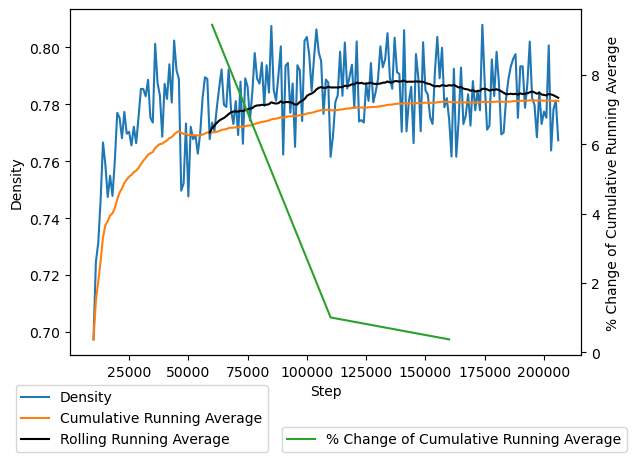

In [16]:
### Robust function to analayze convergence of a property in a simulation
def ensemble_average(filename:str, property:str, tolerance:float = 0.1, window:int = 50, save:bool = True):
    """
    Compute ensemble average of a property from a LAMMPS log file by checking for converge and the plotting the trajectory
    """
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    
    def parse_lammps_log(log_filename:str):
        """
        Parses the LAMMPS log file and extracts data from a Verlet run.
    
        Parameters:
        log_filename (str): Path to the LAMMPS log file.
    
        Returns:
        data (dict): A dictionary where keys are column headers and values are lists of data points.
        """
        data = {}
        in_run = False
        headers = []
        with open(log_filename, 'r') as file:
            for line in file:
                line = line.strip()
    
                # Identify the start of the Verlet run output
                if line.startswith('Step'):
                    headers = line.split()
                    # Initialize data lists for each header
                    for header in headers:
                        data[header] = []
                    in_run = True
                    continue
    
                # If we're inside a run, collect the data
                elif in_run:
                    if not line or line.startswith('Loop time'):
                        # End of data section
                        in_run = False
                        continue
                    else:
                        values = line.split()
                        # Ensure the line has the correct number of values
                        if len(values) == len(headers):
                            for i, value in enumerate(values):
                                # Convert numeric values to float
                                try:
                                    data[headers[i]].append(float(value))
                                except ValueError:
                                    data[headers[i]].append(value)
                        else:
                            # Data line doesn't match header length; end of this data section
                            in_run = False
        return data
    
    converged = False
    
    # Load the log file
    data = parse_lammps_log(filename)
    header = list(data.keys())
    
    # Check if the property is in the headers
    if property in header:
        # Get data from log file
        property_data = data[property]
    else:
        # Handle the error
        raise KeyError(f"The property '{property}' is not found in the log file headers.")
    
    # get data from log file
    timestep_data = data['Step']

    # convert extracted property data into df
    property_df = pd.DataFrame(data=property_data)  

    # calculate cumulative running average
    cum_running_average_df = property_df.expanding().mean()  
    
    # Turn CRA into flat np.array
    cum_running_average = cum_running_average_df.to_numpy().flatten()  
    
    # Looping parameters
    change_of_CRA = []  # log of percent changes not meeting tolerance
    time_change_of_CRA = []  # log of time indexes where tolerance is not met
    time_change_index = -1  # Counter to keep track of when cutoff is done for graphing

    for ii in np.arange(window, len(cum_running_average_df), window):

        point_1 = cum_running_average[ii - window]
        point_2 = cum_running_average[ii]
        percent_change = np.abs(point_1 - point_2) / np.abs(point_2) * 100

        if percent_change >= tolerance:
            time_change_index = time_change_index + 1
            change_of_CRA = np.append(change_of_CRA, percent_change)
            time_change_of_CRA = np.append(time_change_of_CRA, timestep_data[ii])
        else:
            index_of_tolerance_met = ii
            converged = True
            break

    # Graphing
    if save:
        rolling_running_average_df = property_df.rolling(window).mean()
        rolling_running_average = rolling_running_average_df.to_numpy().flatten()
        
        fig, ax1 = plt.subplots()

        ax1.set_xlabel('Step')
        ax1.set_ylabel(property)
        ax1.plot(timestep_data, property_data, label=property)
        ax1.plot(timestep_data, cum_running_average, label='Cumulative Running Average')
        ax1.plot(timestep_data, rolling_running_average, label='Rolling Running Average', color='black')

        plt.legend(loc="lower right", bbox_to_anchor=(0.4, -0.3))

        ax2 = ax1.twinx()  # instantiate cum_running_average second axes that shares the same x-axis
        ax2.set_ylabel('% Change of Cumulative Running Average')  # we already handled the x-label with ax1
        ax2.plot(time_change_of_CRA, change_of_CRA, label='% Change of Cumulative Running Average', color='tab:green')
        
        if converged is True:
            ax2.plot([time_change_of_CRA[time_change_index], time_change_of_CRA[time_change_index]],
                     [np.min(change_of_CRA), np.max(change_of_CRA)],
                     color='tab:red', label='Cutoff')

        fig.tight_layout()  # otherwise the right y-label is slightly
        plt.legend(loc="lower left", bbox_to_anchor=(0.4, -0.3))
        
        if save is not False:
            plt.savefig("./" + property + "_trajectory.png")

    # extract Production data
    if converged is True:
        equilibrium_property_data = property_data[index_of_tolerance_met:]  
        equilibrium_time_data = timestep_data[index_of_tolerance_met:]
        equilibrium_production_data = np.vstack((equilibrium_time_data, equilibrium_property_data))
        print(np.mean(equilibrium_production_data[1]))
        return np.mean(equilibrium_production_data[1])
        
    elif converged is False:
        return converged

## Test the functin
ensemble_average('log.lammps', 'Density', tolerance=0.1, window=50, save=True)